In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

save_dir = '/content/drive/MyDrive/milan_telecom'
files = sorted(os.listdir(save_dir))
print(f"Total files: {len(files)}")
for f in files:
    print(f)

Total files: 77
dataverse_files (1).zip
dataverse_files (2).zip
dataverse_files (3).zip
dataverse_files (4).zip
dataverse_files (5).zip
dataverse_files (6).zip
dataverse_files.zip
processed_data.parquet
sms-call-internet-mi-2013-11-01.txt
sms-call-internet-mi-2013-11-02.txt
sms-call-internet-mi-2013-11-03.txt
sms-call-internet-mi-2013-11-04.txt
sms-call-internet-mi-2013-11-05.txt
sms-call-internet-mi-2013-11-06.txt
sms-call-internet-mi-2013-11-07.txt
sms-call-internet-mi-2013-11-08.txt
sms-call-internet-mi-2013-11-09.txt
sms-call-internet-mi-2013-11-10.txt
sms-call-internet-mi-2013-11-11.txt
sms-call-internet-mi-2013-11-12.txt
sms-call-internet-mi-2013-11-13.txt
sms-call-internet-mi-2013-11-14.txt
sms-call-internet-mi-2013-11-15.txt
sms-call-internet-mi-2013-11-16.txt
sms-call-internet-mi-2013-11-17.txt
sms-call-internet-mi-2013-11-18.txt
sms-call-internet-mi-2013-11-19.txt
sms-call-internet-mi-2013-11-20.txt
sms-call-internet-mi-2013-11-21.txt
sms-call-internet-mi-2013-11-22.txt
sms-c

In [ ]:
import zipfile
import os

save_dir = '/content/drive/MyDrive/milan_telecom'

for filename in sorted(os.listdir(save_dir)):
    if filename.endswith('.zip'):
        zip_path = os.path.join(save_dir, filename)
        print(f"Unzipping {filename}...")
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(save_dir)
        print(f"✓ Done")

print("\nAll unzipped! Checking files...")
all_files = sorted(os.listdir(save_dir))
txt_files = [f for f in all_files if f.endswith('.txt')]
print(f"Total .txt files: {len(txt_files)}")

Unzipping dataverse_files (1).zip...
✓ Done
Unzipping dataverse_files (2).zip...
✓ Done
Unzipping dataverse_files (3).zip...
✓ Done
Unzipping dataverse_files (4).zip...
✓ Done
Unzipping dataverse_files (5).zip...
✓ Done
Unzipping dataverse_files (6).zip...
✓ Done
Unzipping dataverse_files.zip...
✓ Done

All unzipped! Checking files...
Total .txt files: 62


In [ ]:
txt_files = sorted([f for f in os.listdir(save_dir) if f.endswith('.txt')])
print("First 3 files:", txt_files[:3])
print("Last 3 files:", txt_files[-3:])

# Check size of first file
first_file = os.path.join(save_dir, txt_files[0])
size_mb = os.path.getsize(first_file) / (1024*1024)
print(f"\nSize of first file: {size_mb:.1f} MB")

# Peek at first few lines
with open(first_file, 'r') as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i >= 4:
            break

First 3 files: ['sms-call-internet-mi-2013-11-01.txt', 'sms-call-internet-mi-2013-11-02.txt', 'sms-call-internet-mi-2013-11-03.txt']
Last 3 files: ['sms-call-internet-mi-2013-12-30.txt', 'sms-call-internet-mi-2013-12-31.txt', 'sms-call-internet-mi-2014-01-01.txt']

Size of first file: 307.9 MB
1	1383260400000	0	0.08136262351125882
1	1383260400000	39	0.14186425470242922	0.1567870050390246	0.16093793691701822	0.052274848528573205	11.028366381681026
1	1383261000000	0	0.13658782275823106			0.02730046487718618
1	1383261000000	33					0.026137424264286602
1	1383261000000	39	0.27845207746066025	0.11992572014174135	0.1887771729145041	0.13363747203983203	11.100963451409388


In [ ]:
import pandas as pd
import numpy as np
import os

save_dir = '/content/drive/MyDrive/milan_telecom'

# Check memory before loading
import psutil
ram = psutil.virtual_memory()
print(f"Available RAM: {ram.available / 1024**3:.2f} GB")
print(f"Total RAM: {ram.total / 1024**3:.2f} GB")

# Read just one file to understand structure
first_file = os.path.join(save_dir, 'sms-call-internet-mi-2013-11-01.txt')
df_sample = pd.read_csv(first_file, sep='\t', header=None)
print(f"\nColumns: {df_sample.shape[1]}")
print(f"Rows in one file: {df_sample.shape[0]}")
print(f"\nSample:\n{df_sample.head()}")
print(f"\nData types:\n{df_sample.dtypes}")

Available RAM: 10.44 GB
Total RAM: 12.67 GB

Columns: 8
Rows in one file: 4842625

Sample:
   0              1   2         3         4         5         6          7
0  1  1383260400000   0  0.081363       NaN       NaN       NaN        NaN
1  1  1383260400000  39  0.141864  0.156787  0.160938  0.052275  11.028366
2  1  1383261000000   0  0.136588       NaN       NaN  0.027300        NaN
3  1  1383261000000  33       NaN       NaN       NaN       NaN   0.026137
4  1  1383261000000  39  0.278452  0.119926  0.188777  0.133637  11.100963

Data types:
0      int64
1      int64
2      int64
3    float64
4    float64
5    float64
6    float64
7    float64
dtype: object


In [ ]:
import pandas as pd
import numpy as np
import os
import psutil

save_dir = '/content/drive/MyDrive/milan_telecom'

def get_ram_usage():
    ram = psutil.virtual_memory()
    return ram.used / 1024**3

print(f"RAM before loading: {get_ram_usage():.2f} GB")

# Load all files efficiently
chunks = []
txt_files = sorted([f for f in os.listdir(save_dir) if f.endswith('.txt')])

for filename in txt_files:
    filepath = os.path.join(save_dir, filename)
    df = pd.read_csv(
        filepath,
        sep='\t',
        header=None,
        usecols=[0, 1, 2, 5],         # only columns we need
        dtype={0: np.int32, 1: np.int64, 2: np.int16, 5: np.float32}
    )
    # Keep only Italian traffic (country code 39)
    df = df[df[2] == 39]
    # Drop country code column now
    df = df.drop(columns=[2])
    df.columns = ['square_id', 'timestamp', 'internet']
    chunks.append(df)
    print(f"✓ Loaded {filename} — rows kept: {len(df)}")

print(f"\nCombining all files...")
data = pd.concat(chunks, ignore_index=True)
print(f"RAM after loading: {get_ram_usage():.2f} GB")
print(f"Total rows: {len(data)}")
print(f"Memory usage: {data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(data.head())

RAM before loading: 2.22 GB
✓ Loaded sms-call-internet-mi-2013-11-01.txt — rows kept: 1439981
✓ Loaded sms-call-internet-mi-2013-11-02.txt — rows kept: 1439983
✓ Loaded sms-call-internet-mi-2013-11-03.txt — rows kept: 1439957
✓ Loaded sms-call-internet-mi-2013-11-04.txt — rows kept: 1439972
✓ Loaded sms-call-internet-mi-2013-11-05.txt — rows kept: 1439976
✓ Loaded sms-call-internet-mi-2013-11-06.txt — rows kept: 1439974
✓ Loaded sms-call-internet-mi-2013-11-07.txt — rows kept: 1439978
✓ Loaded sms-call-internet-mi-2013-11-08.txt — rows kept: 1439972
✓ Loaded sms-call-internet-mi-2013-11-09.txt — rows kept: 1439975
✓ Loaded sms-call-internet-mi-2013-11-10.txt — rows kept: 1439982
✓ Loaded sms-call-internet-mi-2013-11-11.txt — rows kept: 1439984
✓ Loaded sms-call-internet-mi-2013-11-12.txt — rows kept: 1439972
✓ Loaded sms-call-internet-mi-2013-11-13.txt — rows kept: 1439974
✓ Loaded sms-call-internet-mi-2013-11-14.txt — rows kept: 1439970
✓ Loaded sms-call-internet-mi-2013-11-15.txt — r

In [ ]:
# Convert timestamp from milliseconds to datetime
data['timestamp'] = pd.to_datetime(data['timestamp'], unit='ms')

# Fill missing internet values with 0
data['internet'] = data['internet'].fillna(0)

print(f"Date range: {data['timestamp'].min()} to {data['timestamp'].max()}")
print(f"Unique squares: {data['square_id'].nunique()}")
print(f"\nSample after conversion:")
print(data.head())

# Save to Drive so we don't reload next time
processed_path = '/content/drive/MyDrive/milan_telecom/processed_data.parquet'
data.to_parquet(processed_path, index=False)
print(f"\n✓ Saved processed data to Drive!")

Date range: 2013-10-31 23:00:00 to 2014-01-01 22:50:00
Unique squares: 10000

Sample after conversion:
   square_id           timestamp  internet
0          1 2013-10-31 23:00:00  0.160938
1          1 2013-10-31 23:10:00  0.188777
2          1 2013-10-31 23:20:00  0.134176
3          1 2013-10-31 23:30:00  0.027300
4          1 2013-10-31 23:40:00  0.053438

✓ Saved processed data to Drive!


In [ ]:
# Find total traffic per square over the full 2 months
total_traffic = data.groupby('square_id')['internet'].sum()

# Find highest traffic area
top_square = total_traffic.idxmax()
print(f"Highest traffic square ID: {top_square}")
print(f"Total traffic: {total_traffic[top_square]:.2f}")

# Confirm our two fixed squares exist
print(f"\nSquare 4159 total traffic: {total_traffic[4159]:.2f}")
print(f"Square 4556 total traffic: {total_traffic[4556]:.2f}")

# Our 3 target areas
target_squares = [top_square, 4159, 4556]
print(f"\nTarget squares: {target_squares}")

Highest traffic square ID: 5059
Total traffic: 652916.31

Square 4159 total traffic: 73654.13
Square 4556 total traffic: 199223.72

Target squares: [np.int32(5059), 4159, 4556]


In [ ]:
# Extract data for our 3 target squares
target_squares = [5059, 4159, 4556]

area_data = {}
for sq in target_squares:
    df_sq = data[data['square_id'] == sq][['timestamp', 'internet']].copy()
    df_sq = df_sq.sort_values('timestamp').set_index('timestamp')
    # Resample to fill any missing 10-min intervals with 0
    df_sq = df_sq.resample('10min').sum()
    area_data[sq] = df_sq
    print(f"Square {sq}: {len(df_sq)} time intervals")
    print(f"  From: {df_sq.index.min()}")
    print(f"  To:   {df_sq.index.max()}")
    print(f"  Mean traffic: {df_sq['internet'].mean():.4f}")
    print()

Square 5059: 8928 time intervals
  From: 2013-10-31 23:00:00
  To:   2014-01-01 22:50:00
  Mean traffic: 73.1313

Square 4159: 8928 time intervals
  From: 2013-10-31 23:00:00
  To:   2014-01-01 22:50:00
  Mean traffic: 8.2498

Square 4556: 8928 time intervals
  From: 2013-10-31 23:00:00
  To:   2014-01-01 22:50:00
  Mean traffic: 22.3145



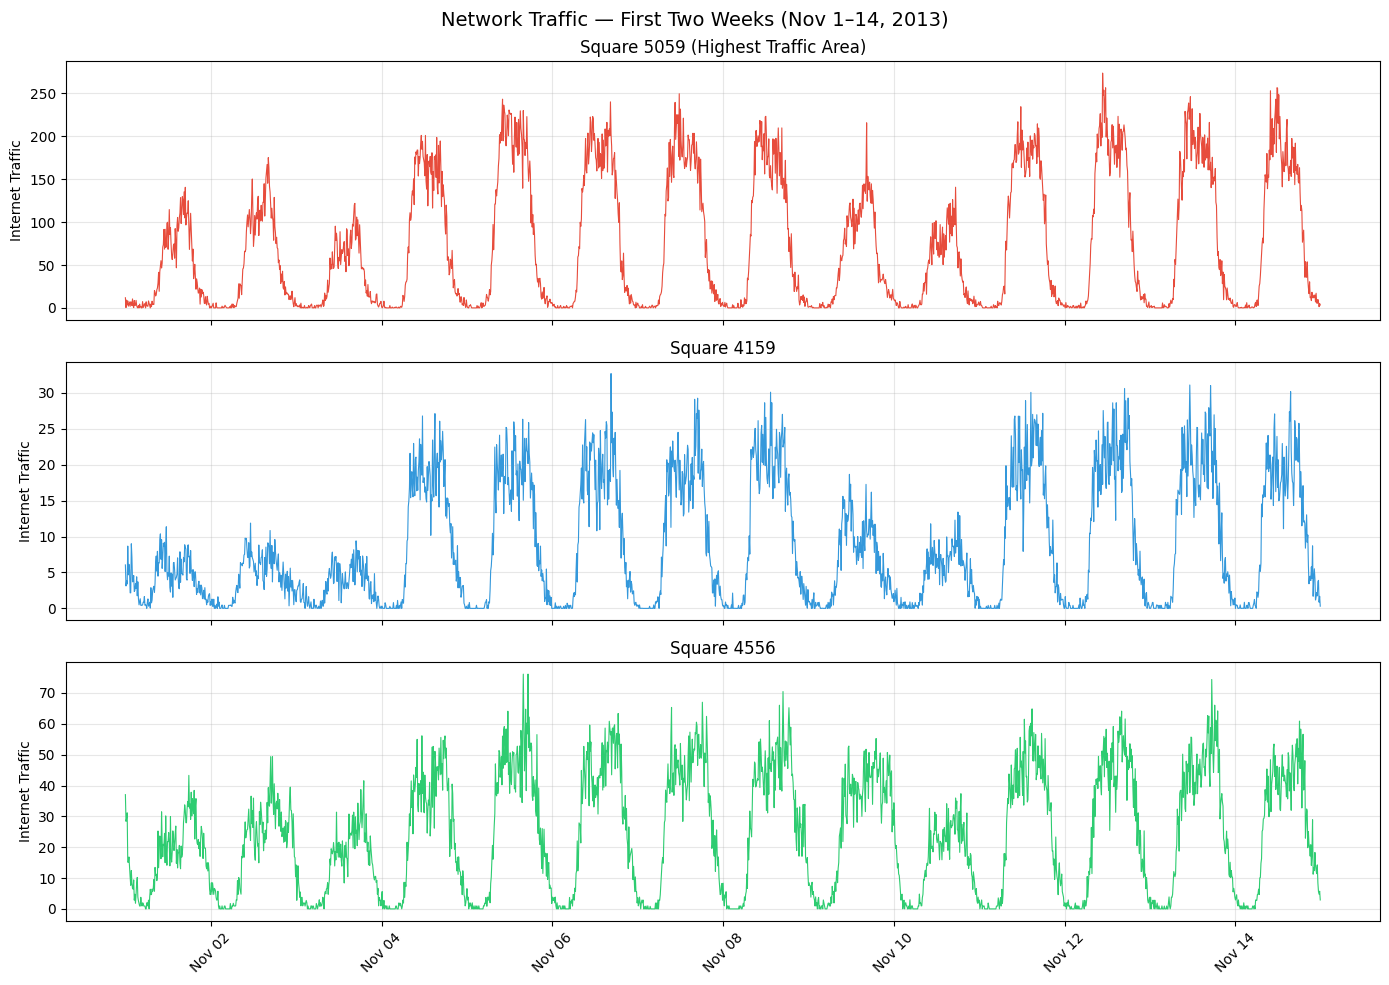

✓ Plot saved!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# First two weeks only
start = '2013-11-01'
end = '2013-11-14'

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

titles = {
    5059: 'Square 5059 (Highest Traffic Area)',
    4159: 'Square 4159',
    4556: 'Square 4556'
}
colors = ['#e74c3c', '#3498db', '#2ecc71']

for i, (sq, color) in enumerate(zip(target_squares, colors)):
    ts = area_data[sq][start:end]
    axes[i].plot(ts.index, ts['internet'], color=color, linewidth=0.8)
    axes[i].set_title(titles[sq], fontsize=12)
    axes[i].set_ylabel('Internet Traffic')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    axes[i].xaxis.set_major_locator(mdates.DayLocator(interval=2))
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Network Traffic — First Two Weeks (Nov 1–14, 2013)', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan_telecom/task2_timeseries.png', dpi=150)
plt.show()
print("✓ Plot saved!")

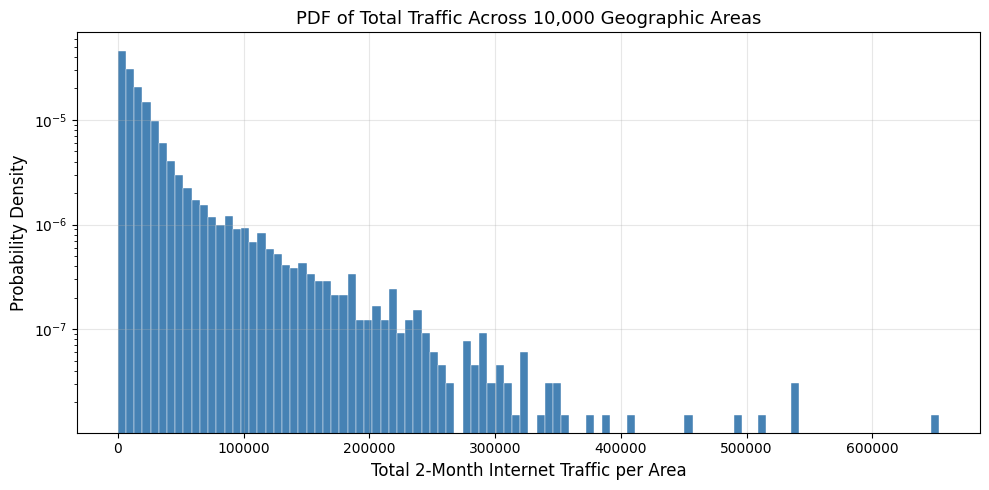

✓ PDF plot saved!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Total traffic per square over full 2 months
total_traffic = data.groupby('square_id')['internet'].sum()

plt.figure(figsize=(10, 5))
plt.hist(total_traffic, bins=100, density=True, color='steelblue', edgecolor='white', linewidth=0.3)
plt.xlabel('Total 2-Month Internet Traffic per Area', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('PDF of Total Traffic Across 10,000 Geographic Areas', fontsize=13)
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan_telecom/task2_pdf.png', dpi=150)
plt.show()
print("✓ PDF plot saved!")

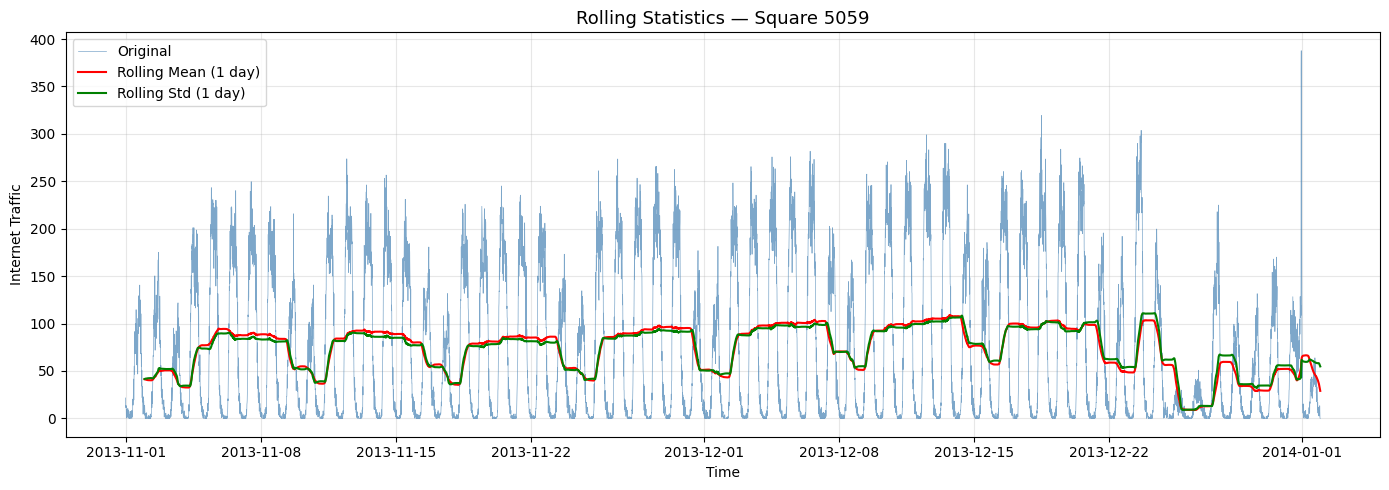

Running ADF test...
ADF Statistic: -18.4454
p-value: 0.000000
Critical Values:
   1%: -3.4311
   5%: -2.8619
   10%: -2.5669

✓ Series is STATIONARY (p < 0.05)


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Use square 5059 for stationarity analysis
ts = area_data[5059]['internet']

# Rolling statistics
window = 144  # 1 day = 144 intervals of 10 minutes

rolling_mean = ts.rolling(window=window).mean()
rolling_std = ts.rolling(window=window).std()

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts, color='steelblue', linewidth=0.5, label='Original', alpha=0.7)
ax.plot(rolling_mean, color='red', linewidth=1.5, label='Rolling Mean (1 day)')
ax.plot(rolling_std, color='green', linewidth=1.5, label='Rolling Std (1 day)')
ax.set_title('Rolling Statistics — Square 5059', fontsize=13)
ax.set_xlabel('Time')
ax.set_ylabel('Internet Traffic')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan_telecom/task2_rolling_stats.png', dpi=150)
plt.show()

# ADF Test
print("Running ADF test...")
adf_result = adfuller(ts, autolag='AIC')
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.6f}")
print(f"Critical Values:")
for key, val in adf_result[4].items():
    print(f"   {key}: {val:.4f}")

if adf_result[1] < 0.05:
    print("\n✓ Series is STATIONARY (p < 0.05)")
else:
    print("\n✗ Series is NON-STATIONARY (p >= 0.05)")

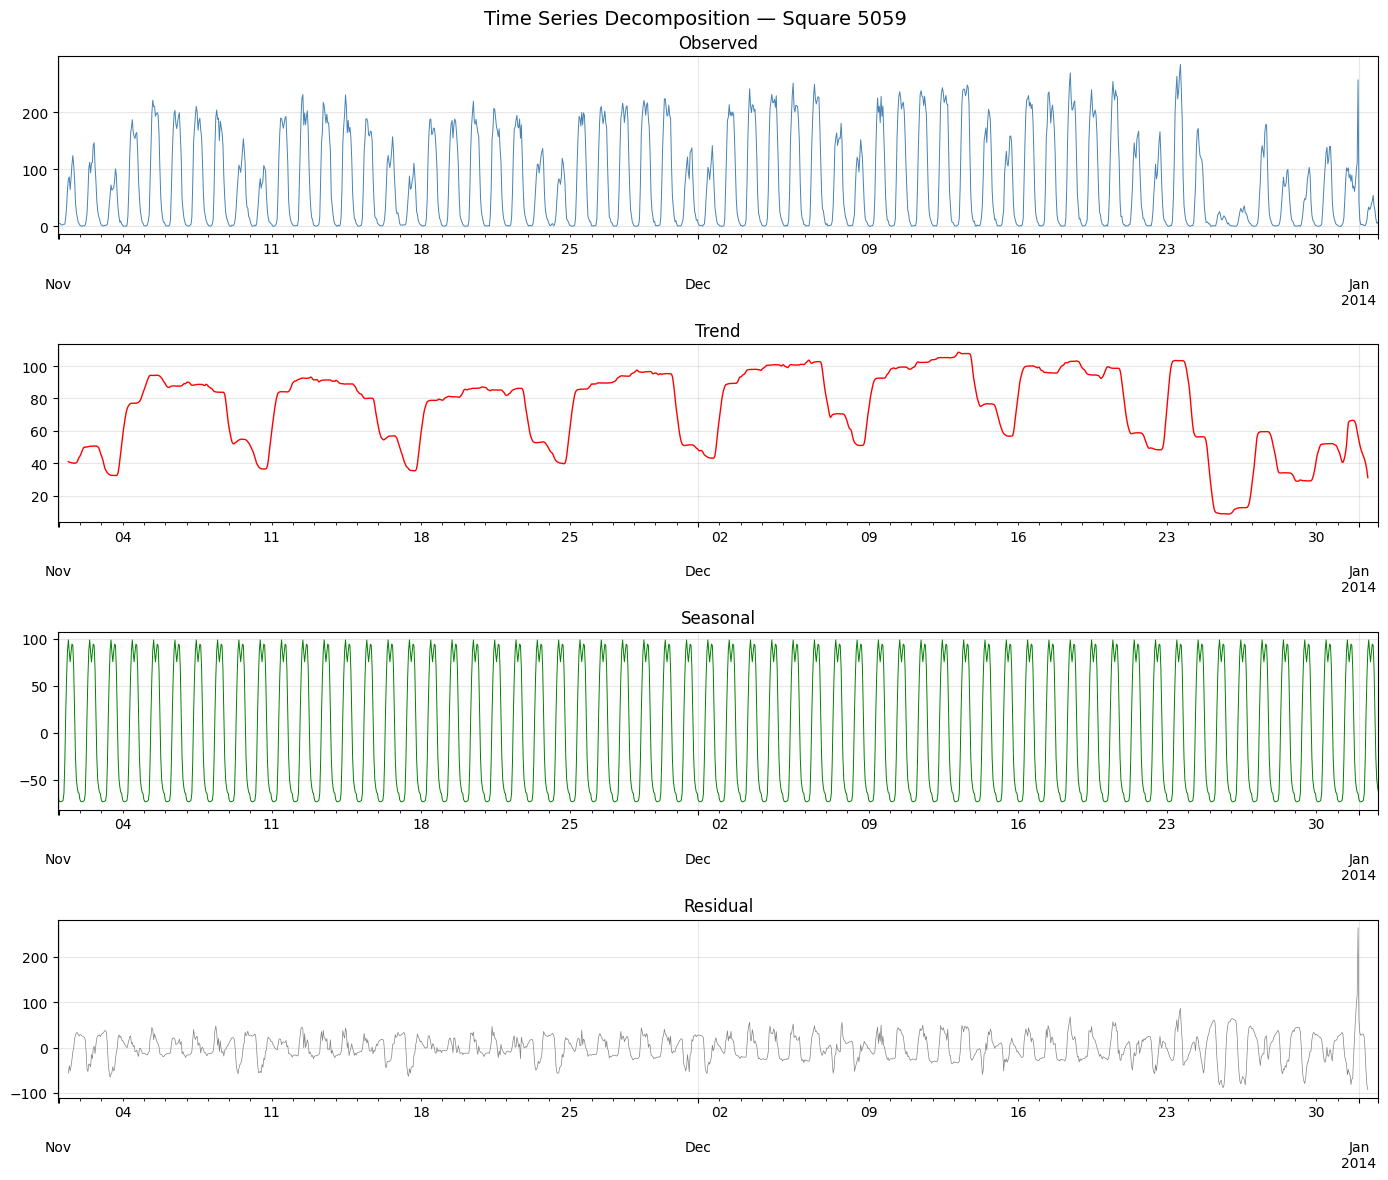

✓ Saved!


In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Use daily resampled data for cleaner decomposition
ts_daily = area_data[5059]['internet'].resample('h').mean()

# Decompose with period = 24 hours
decomposition = seasonal_decompose(ts_daily, model='additive', period=24)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
decomposition.observed.plot(ax=axes[0], color='steelblue', linewidth=0.7)
axes[0].set_title('Observed')
decomposition.trend.plot(ax=axes[1], color='red', linewidth=1)
axes[1].set_title('Trend')
decomposition.seasonal.plot(ax=axes[2], color='green', linewidth=0.7)
axes[2].set_title('Seasonal')
decomposition.resid.plot(ax=axes[3], color='gray', linewidth=0.5)
axes[3].set_title('Residual')

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('')

plt.suptitle('Time Series Decomposition — Square 5059', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan_telecom/task2_decomposition.png', dpi=150)
plt.show()
print("✓ Saved!")

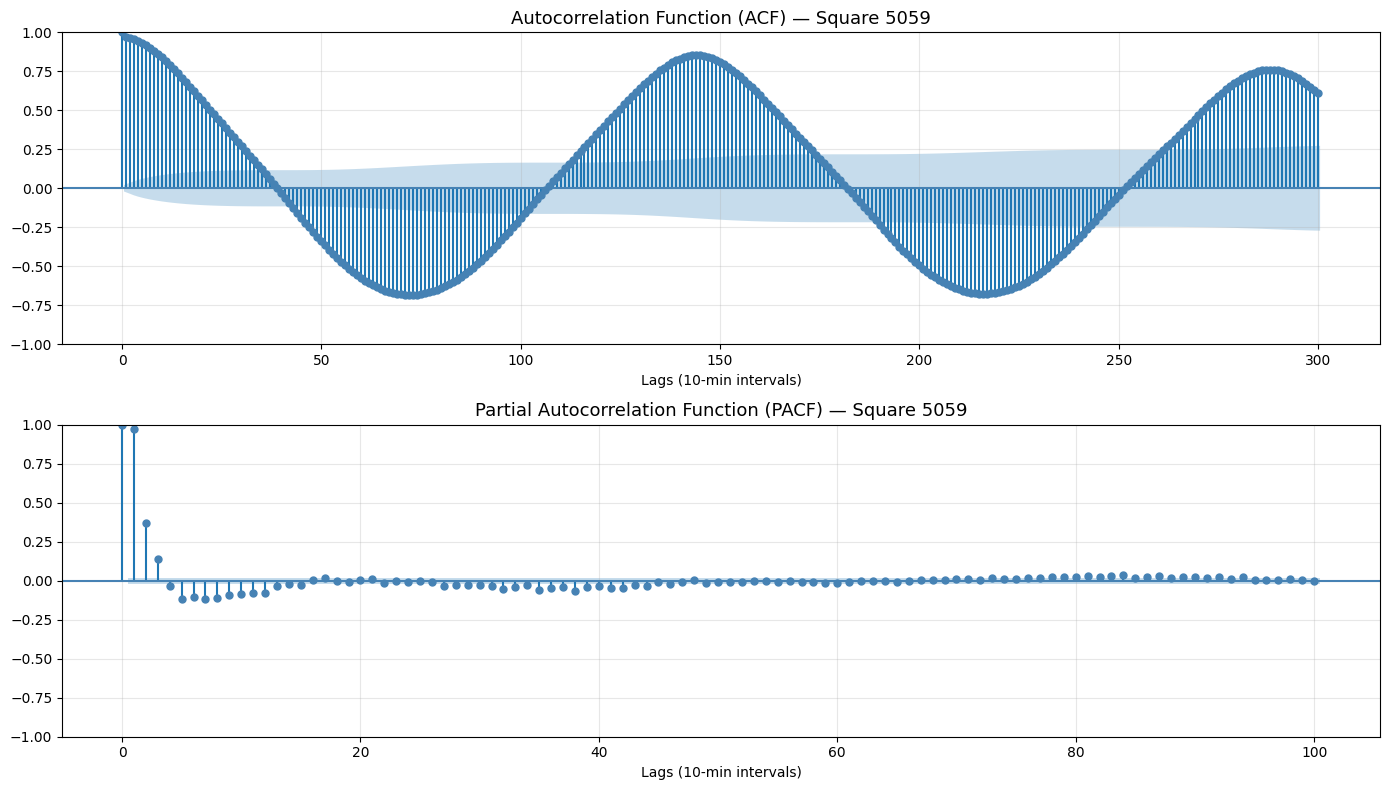

✓ Saved!


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

ts = area_data[5059]['internet']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(ts, lags=300, ax=axes[0], color='steelblue', alpha=0.05)
axes[0].set_title('Autocorrelation Function (ACF) — Square 5059', fontsize=13)
axes[0].set_xlabel('Lags (10-min intervals)')
axes[0].grid(True, alpha=0.3)

plot_pacf(ts, lags=100, ax=axes[1], color='steelblue', alpha=0.05, method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF) — Square 5059', fontsize=13)
axes[1].set_xlabel('Lags (10-min intervals)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan_telecom/task2_acf_pacf.png', dpi=150)
plt.show()
print("✓ Saved!")

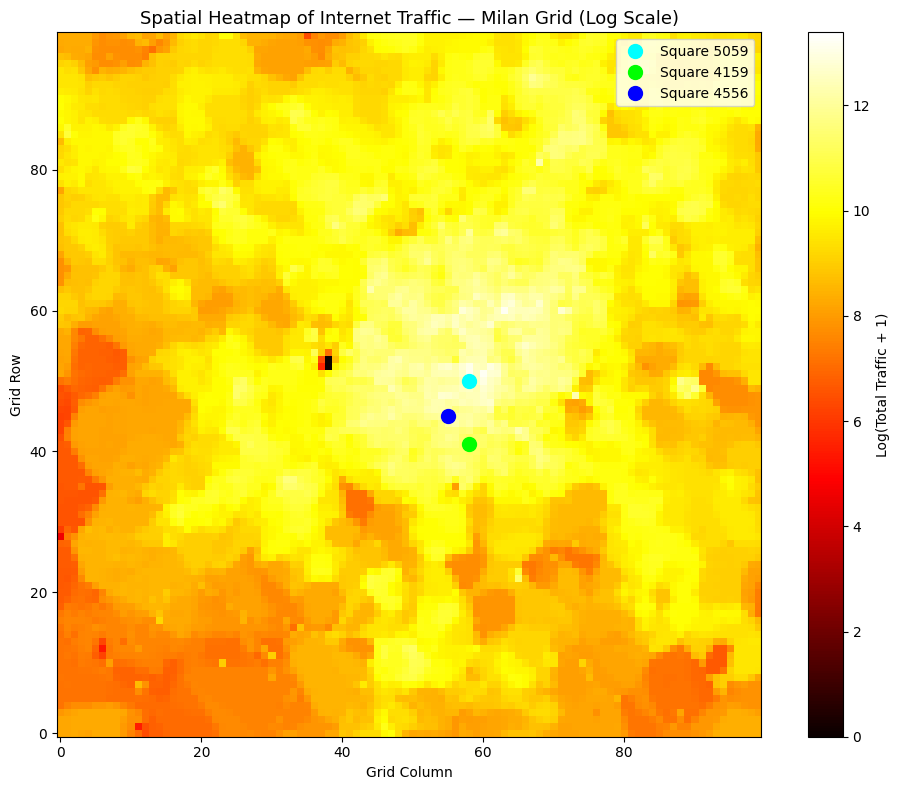

✓ Saved!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Total traffic per square
total_traffic = data.groupby('square_id')['internet'].sum()

# The grid is 100x100, square IDs go from 1 to 10000
# Row = (square_id - 1) // 100, Col = (square_id - 1) % 100
grid = np.zeros((100, 100))
for sq_id, traffic in total_traffic.items():
    row = (sq_id - 1) // 100
    col = (sq_id - 1) % 100
    grid[row, col] = traffic

plt.figure(figsize=(10, 8))
plt.imshow(np.log1p(grid), cmap='hot', origin='lower')
plt.colorbar(label='Log(Total Traffic + 1)')
plt.title('Spatial Heatmap of Internet Traffic — Milan Grid (Log Scale)', fontsize=13)
plt.xlabel('Grid Column')
plt.ylabel('Grid Row')

# Mark our 3 target squares
for sq, color, label in [(5059, 'cyan', '5059'), (4159, 'lime', '4159'), (4556, 'blue', '4556')]:
    row = (sq - 1) // 100
    col = (sq - 1) % 100
    plt.plot(col, row, 'o', color=color, markersize=10, label=f'Square {label}')

plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan_telecom/task2_heatmap.png', dpi=150)
plt.show()
print("✓ Saved!")

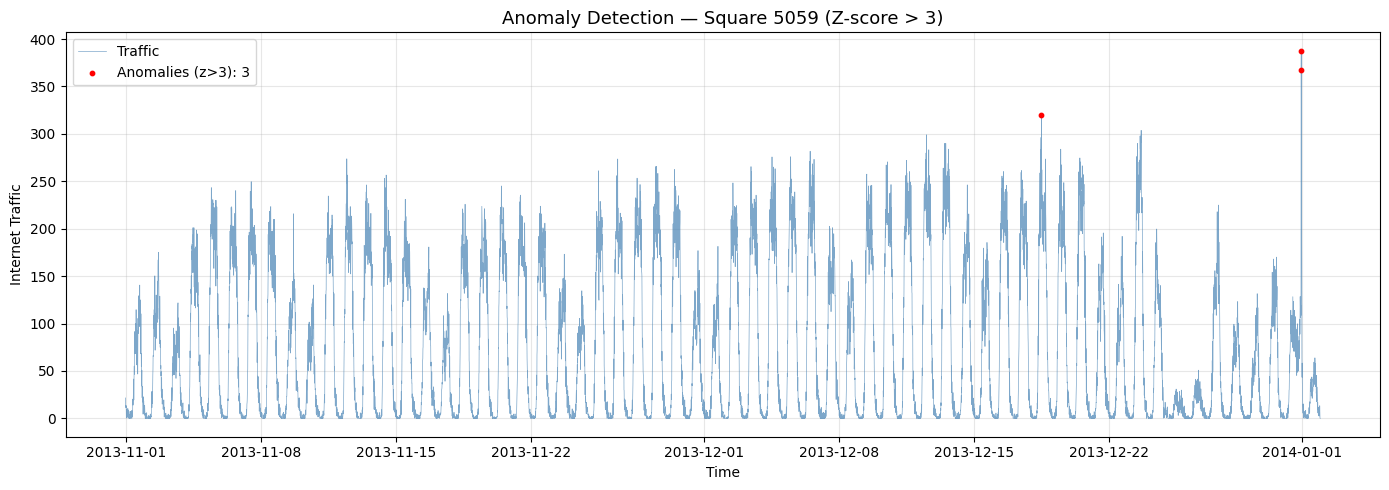

Top 10 highest anomalies:
timestamp
2013-12-31 23:10:00    387.734833
2013-12-31 23:00:00    367.245789
2013-12-18 11:40:00    319.438507
Name: internet, dtype: float32


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

ts = area_data[5059]['internet']

# Detect anomalies using z-score
mean = ts.mean()
std = ts.std()
z_scores = (ts - mean) / std
anomalies = ts[np.abs(z_scores) > 3]

plt.figure(figsize=(14, 5))
plt.plot(ts, color='steelblue', linewidth=0.5, label='Traffic', alpha=0.7)
plt.scatter(anomalies.index, anomalies.values, color='red', s=10, zorder=5, label=f'Anomalies (z>3): {len(anomalies)}')
plt.title('Anomaly Detection — Square 5059 (Z-score > 3)', fontsize=13)
plt.xlabel('Time')
plt.ylabel('Internet Traffic')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan_telecom/task2_anomalies.png', dpi=150)
plt.show()

# Print top 10 anomalies
print("Top 10 highest anomalies:")
print(anomalies.sort_values(ascending=False).head(10))

In [ ]:
import numpy as np
import pandas as pd

# Define train/test split
test_start = '2013-12-16'
test_end = '2013-12-22 23:50:00'

# Prepare data for each area
train_data = {}
test_data = {}

for sq in target_squares:
    ts = area_data[sq]['internet']
    train_data[sq] = ts[ts.index < test_start]
    test_data[sq] = ts[(ts.index >= test_start) & (ts.index <= test_end)]
    print(f"Square {sq}:")
    print(f"  Train: {len(train_data[sq])} intervals ({train_data[sq].index.min()} to {train_data[sq].index.max()})")
    print(f"  Test:  {len(test_data[sq])} intervals ({test_data[sq].index.min()} to {test_data[sq].index.max()})")
    print()

Square 5059:
  Train: 6486 intervals (2013-10-31 23:00:00 to 2013-12-15 23:50:00)
  Test:  1008 intervals (2013-12-16 00:00:00 to 2013-12-22 23:50:00)

Square 4159:
  Train: 6486 intervals (2013-10-31 23:00:00 to 2013-12-15 23:50:00)
  Test:  1008 intervals (2013-12-16 00:00:00 to 2013-12-22 23:50:00)

Square 4556:
  Train: 6486 intervals (2013-10-31 23:00:00 to 2013-12-15 23:50:00)
  Test:  1008 intervals (2013-12-16 00:00:00 to 2013-12-22 23:50:00)



In [ ]:
import numpy as np

def mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))

def mape(actual, predicted):
    # Avoid division by zero
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

def evaluate(actual, predicted, model_name, square_id):
    m = mae(actual, predicted)
    mp = mape(actual, predicted)
    r = rmse(actual, predicted)
    print(f"{model_name} — Square {square_id}:")
    print(f"  MAE:  {m:.4f}")
    print(f"  MAPE: {mp:.2f}%")
    print(f"  RMSE: {r:.4f}")
    return {'model': model_name, 'square': square_id, 'MAE': m, 'MAPE': mp, 'RMSE': r}

print("✓ Metrics defined!")

✓ Metrics defined!


In [ ]:
import time
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

sarima_results = {}
sarima_times = {}

for sq in target_squares:
    print(f"\nFitting SARIMA for Square {sq}...")

    # Use only last 1 week of training data
    train = train_data[sq].values[-1008:]  # 1 week
    test = test_data[sq].values

    start_time = time.time()

    # Very simple ARIMA - fast to fit
    model = SARIMAX(
        train,
        order=(2, 0, 1),
        seasonal_order=(1, 0, 1, 144),
        enforce_stationarity=False,
        enforce_invertibility=False,
        concentrate_scale=True
    )
    fitted = model.fit(disp=False, maxiter=30, method='powell')
    train_time = time.time() - start_time

    # Forecast
    forecast_start = time.time()
    forecast = fitted.forecast(steps=len(test))
    forecast = np.maximum(forecast, 0)
    forecast_time = time.time() - forecast_start

    sarima_results[sq] = {'actual': test, 'predicted': forecast}
    sarima_times[sq] = {'train': train_time, 'forecast': forecast_time}

    print(f"  ✓ Done — Train time: {train_time:.1f}s")

print("\nAll SARIMA models fitted!")


Fitting SARIMA for Square 5059...
  ✓ Done — Train time: 577.5s

Fitting SARIMA for Square 4159...
  ✓ Done — Train time: 472.0s

Fitting SARIMA for Square 4556...
  ✓ Done — Train time: 794.7s

All SARIMA models fitted!
